In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

import src.utils.utils as utils
import src.utils.losses as losses
import src.utils.plots as plots
import src.utils.extractor as extractor
import src.models.models as models
import src.models.foundation_models as rsfm
import src.models.srvit as srvit

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

Using device: cuda:0


In [ ]:
# remove = [1,2,3,108,109,110,111,112,154,155,156,157,158,159,160,161,162,163,164,165,166,220,221,222,223,224]
# for i, r in enumerate(remove):
#     remove[i] = r-1

In [ ]:
dataset = "urban"
data = io.loadmat(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}.mat")
Y = torch.tensor(data["X"], dtype=torch.float).permute(2,0,1)
mask = torch.ones(Y.shape[0], dtype=bool)
mask[remove] = False
Y = Y[mask]
Y = torch.concat([Y[:104,:,:], Y[105:,:,:]])
B, H, W = Y.shape

shift = 8
c = 3
new_H = 224

Y1 = Y[:, :224, :224].unsqueeze(0)
Y2 = Y[:, shift:224+shift, shift:224+shift].unsqueeze(0)
# Y2 = Y[:, 224:448, 224:448].unsqueeze(0)

with open(f"{global_path}/SS-HSU_benchmark/datasets/cuprite_wavelength.txt", "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]
wavelengths = [wave for i, wave in enumerate(wavelengths) if i not in remove]
wavelengths = wavelengths[:104]+wavelengths[105:]

In [15]:
n_features = 1

check_point = torch.load('/home/ids/edabier/HSU/DOFA/checkpoints/DOFA_ViT_base_e100.pth', map_location=dev)
fm = rsfm.OFAViT(
    img_size=224, patch_size=16, embed_dim=768, depth=12, num_heads=12, out_indices=[11], mlp_ratio=4,
    norm_layer=partial(nn.LayerNorm, eps=1e-6), use_cls=False, extend_cls=False)
fm.load_state_dict(check_point, strict=False)
features1 = rsfm.get_dofa_features(fm, Y1, wavelengths)
D = int(features1.shape[0]/1)

alpha = int(features1.shape[1]**0.5)
unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, n_features=n_features, use_cls=False)

In [ ]:
epochs, lr = 200, 0.002

optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

n_xp = 15
sads, sads_a, mses = [], [], []

E_hats1, A_hats1 = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)

for n in range(n_xp):

    model = rsfm.Unmixing_from_features(D=D, alpha=alpha, H=new_H, B=B, c=c, n_features=n_features, use_cls=False, is_cnnaeu=False)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y1/Y1.max(), c, is_unmixer=True, normalize=False)

    model = model.to(dev)
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for epoch in range(epochs):
        
        optimizer.zero_grad()
        
        Y1, features1 = rsfm.extract_f(fm, Y1, new_H, wavelengths, use_cls=False)
        E_hat, A_hat, Y_hat = model(features1)
        loss = model.loss(Y, Y_hat, A_hat, E_hat)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
        optimizer.step()

        if hasattr(model, 'decoder'):
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
        
        del E_hat, A_hat, Y_hat, features1
        
    model.eval()
    
    with torch.no_grad():
        _, features1 = rsfm.extract_f(fm, Y1, new_H, wavelengths, use_cls=False)
        E_hat, A_hat, _ = model(features1)

    E_hats1[n] = E_hat
    A_hats1[n] = A_hat.squeeze(0)

E_hat1 = torch.mean(E_hats1, dim=0)
A_hat1 = torch.mean(A_hats1, dim=0)
# plots.compute_metrics_and_plot(E_hat1, A_hat1, normalize_E=True, normalize_A=True)

E_hats2, A_hats2 = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)

for n in range(n_xp):

    model = rsfm.Unmixing_from_features(D=D, alpha=alpha, H=new_H, B=B, c=c, n_features=n_features, use_cls=False, is_cnnaeu=False)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y2/Y2.max(), c, is_unmixer=True, normalize=False)

    model = model.to(dev)
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for epoch in range(epochs):
        
        optimizer.zero_grad()
        
        Y2, features2 = rsfm.extract_f(fm, Y2, new_H, wavelengths, use_cls=False)
        E_hat, A_hat, Y_hat = model(features2)
        loss = model.loss(Y, Y_hat, A_hat, E_hat)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
        optimizer.step()

        if hasattr(model, 'decoder'):
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
        
        del E_hat, A_hat, Y_hat, features2
        
    model.eval()
    
    with torch.no_grad():
        _, features2 = rsfm.extract_f(fm, Y2, new_H, wavelengths, use_cls=False)
        E_hat, A_hat, _ = model(features2)

    E_hats2[n] = E_hat
    A_hats2[n] = A_hat.squeeze(0)

E_hat2 = torch.mean(E_hats2, dim=0)
A_hat2 = torch.mean(A_hats2, dim=0)
plots.compute_metrics_and_plot(E_hat1, A_hat1, A_hat2, E_hat2, normalize_E=True, normalize_A=True)

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build 

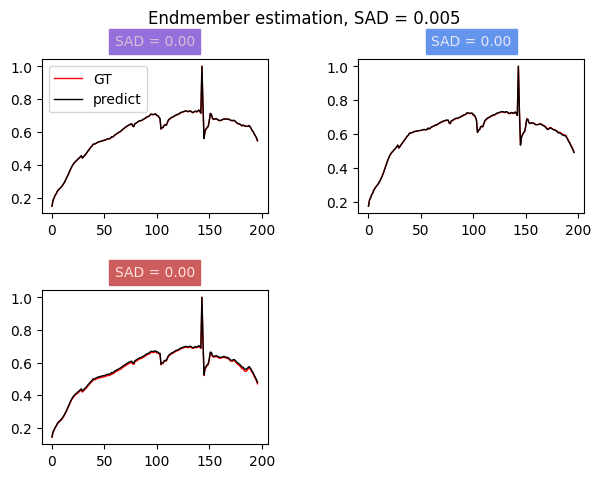

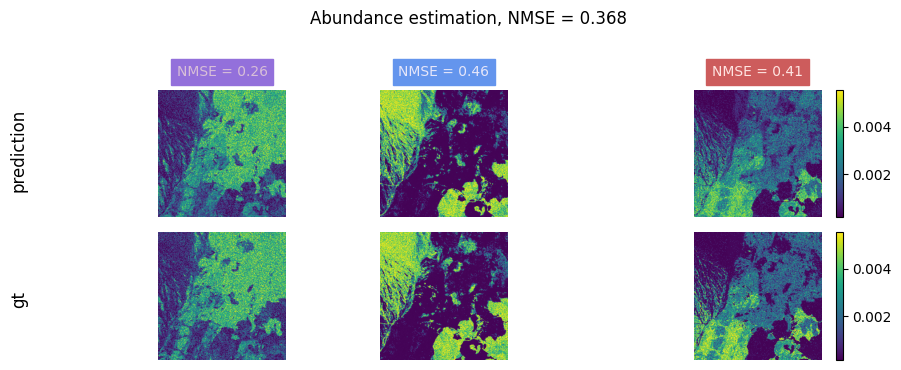

In [18]:
plots.compute_metrics_and_plot(E_hat1, A_hat1, A_hat2, E_hat2, normalize_E=True, normalize_A=True)